# Experiments
## RandomAlgorithm experiment

### Read configuration


### Plot RandomAlgorithm Experiment

In [ ]:
# DO NOT RUN THIS CELL - OLD TEST
import matplotlib.pyplot as plt

target_instance = "tai_20_10_0"
instance_df = csv_df[csv_df["Instance"] == target_instance].copy()
if instance_df.empty:
    raise ValueError(f"Instance '{target_instance}' not found in {csv_path.name}.")

best_cost = instance_df["BestCost"].min()
instance_df["RelativeBestCostPct"] = ((instance_df["BestCost"] / best_cost) - 1.0) * 100.0

ax = instance_df.plot(
    x="Evaluations",
    y="RelativeBestCostPct",
    marker="o",
    figsize=(10, 6),
    logx=True,
    legend=False,
    color="#1f77b4",
)

ax.set_xlabel("Sample size")
ax.set_ylabel("Best solution relative to best found [%]")
ax.set_title(f"Relative best solution vs sample size ({target_instance})")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# All algorithm comparison test

## Read algorithm comparison experiment configuration

In [ ]:
from pathlib import Path
import subprocess

from file_io import list_supported_experiment_files, EXPERIMENTS_ROOT, EXPERIMENT_CONFIG_NAME, REPO_ROOT

files = list_supported_experiment_files(EXPERIMENTS_ROOT)
config_path = EXPERIMENTS_ROOT / "tai_all_default_all_algorithms" / EXPERIMENT_CONFIG_NAME

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

repo_root = REPO_ROOT
print("Running:", " ".join(cmd))
result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(result.stdout)
if result.stderr.strip():
    print("STDERR:\n" + result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {result.returncode}")
print("ExperimentRunner finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms\experimentrunner.json
Experiment Runner
Running Random_10000_s12345 on tai_100_10_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_100_20_0...
Running Evolutionary_p100_g100_s12345 on tai_500_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_10_0 (seed 12345)...
Running Random_10000_s12345 on tai_100_20_0 (seed 12345)...
Running Random_10000_s12345 on tai_20_20_0 (seed 12345)...
Running Evolutionary_p100_g100_s12345 on tai_20_5_0 (seed 12345)...
Running Random_10000_s12345 on tai_500_20_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_500_20_0...
Running Evolutionary_p100_g100_s12345 on tai_100_20_0 (seed 12345)...
Running SimulatedAnnealing_nSwap_i10000_s12345 on tai_20_5_0...
Running SimulatedAnn

## Plot all algorithm comparison

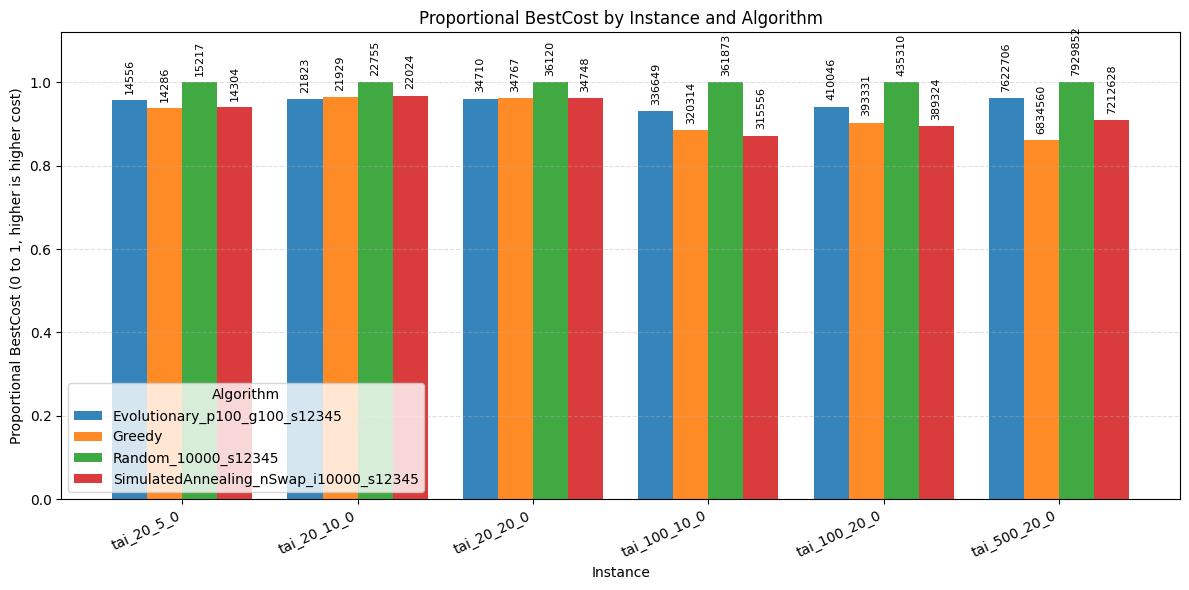

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from file_io import read_csv, find_experiment_results_csv

csv_path = find_experiment_results_csv()
df = read_csv(csv_path)
instance_order = df["Instance"].drop_duplicates().tolist()

pivot = df.pivot_table(
    index="Instance",
    columns="Algorithm",
    values="BestCost",
    aggfunc="min",
)
pivot = pivot.reindex(instance_order)

# Per-instance proportional score in [0, 1]
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

instances = score_pivot.index.to_list()
algorithms = score_pivot.columns.to_list()
x = np.arange(len(instances))
width = 0.8 / max(len(algorithms), 1)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, alg in enumerate(algorithms):
    offset = (idx - (len(algorithms) - 1) / 2) * width
    heights = score_pivot[alg].values
    bars = ax.bar(
        x + offset,
        heights,
        width=width,
        label=alg,
        alpha=0.9,
    )

    # Show BestCost values on bars.
    for bar, cost in zip(bars, pivot[alg].values):
        if pd.notna(cost):
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.015,
                f"{int(cost)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("Proportional BestCost by Instance and Algorithm")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Algorithm")
plt.tight_layout()
plt.show()

# 2 Parameter Evolutionary test

## Run 2D evolutionary experiment

In [8]:
from file_io import EXPERIMENTS_ROOT, REPO_ROOT
import subprocess
repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "tai_20_5_0_evolutionary_population_generations_2d_256" / "experimentrunner.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
 )

print(run_result.stdout)
if run_result.stderr.strip():
    print("STDERR:\n" + run_result.stderr)
if run_result.returncode != 0:
    raise RuntimeError(f"ExperimentRunner failed with exit code {run_result.returncode}")


Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256\experimentrunner.json
Experiment Runner
Running Evolutionary_p160_g10_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p30_g40_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p30_g60_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p130_g50_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p120_g80_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p70_g40_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p40_g70_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p80_g140_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p50_g10_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p60_g150_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p150_g20_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p70_g30_s0 on tai_20_5_0 (seed 0)...
Running Evolutionary_p100_g110_s0 on tai_20_5_0 (seed 0)...
Running Evolutio

## Plot 2D Pop/Gen experiment

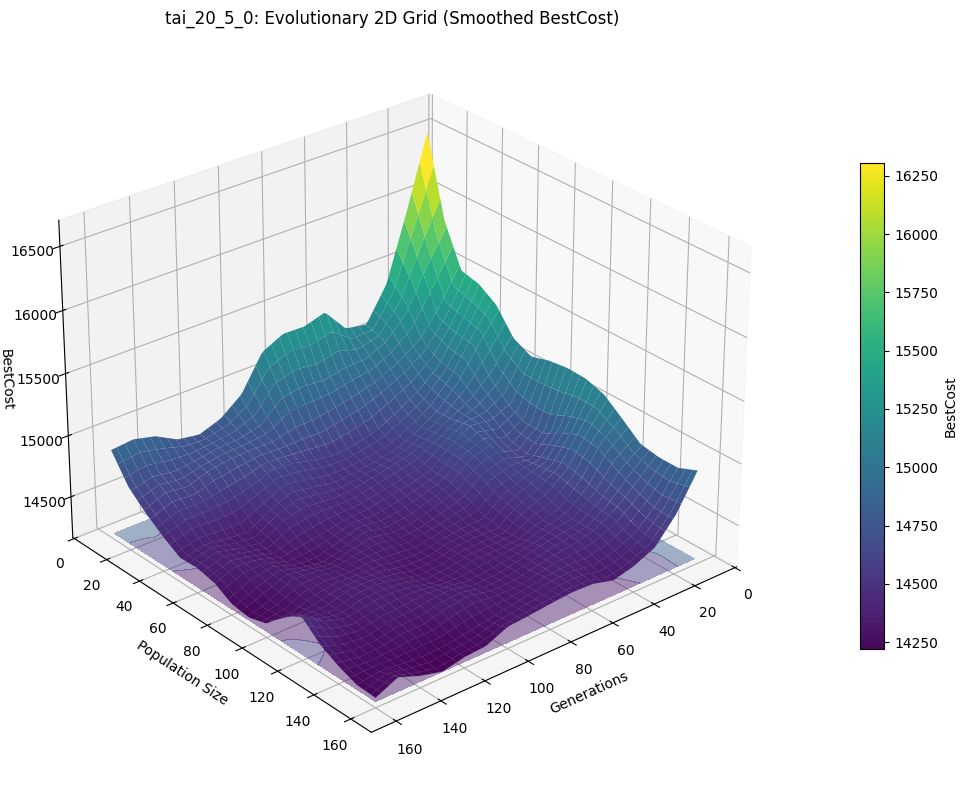

In [10]:
import re

from file_io import EXPERIMENTS_ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = EXPERIMENTS_ROOT / "tai_20_5_0_evolutionary_population_generations_2d_256" / "experiment_results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv}")

df = pd.read_csv(results_csv)
df = df[df["Instance"] == "tai_20_5_0"].copy()

pattern = re.compile(r"Evolutionary_p(?P<p>\d+)_g(?P<g>\d+)_s(?P<s>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["PopulationSize"] = pd.to_numeric(parsed["p"], errors="coerce")
df["Generations"] = pd.to_numeric(parsed["g"], errors="coerce")
df = df.dropna(subset=["PopulationSize", "Generations", "BestCost"]).copy()

df["PopulationSize"] = df["PopulationSize"].astype(int)
df["Generations"] = df["Generations"].astype(int)

surface_df = df.pivot_table(
    index="Generations",
    columns="PopulationSize",
    values="BestCost",
    aggfunc="min",
).sort_index().sort_index(axis=1)

# Optional (install once if needed): pip install scipy
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

# Original regular grid
g_vals = surface_df.index.to_numpy(dtype=float)          # Generations
p_vals = surface_df.columns.to_numpy(dtype=float)        # PopulationSize
Z = surface_df.to_numpy(dtype=float)

# 1) Mild smoothing on original grid
Z_smooth = gaussian_filter(Z, sigma=0.8)

# 2) Upsample to a denser grid for a smoother surface
p_dense = np.linspace(p_vals.min(), p_vals.max(), 120)
g_dense = np.linspace(g_vals.min(), g_vals.max(), 120)
P_dense, G_dense = np.meshgrid(p_dense, g_dense)

interp = RegularGridInterpolator((g_vals, p_vals), Z_smooth, method="linear")
pts = np.column_stack([G_dense.ravel(), P_dense.ravel()])
Z_dense = interp(pts).reshape(G_dense.shape)

# 3D plot (flipped axes: X=Generations, Y=Population Size)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(
    G_dense,
    P_dense,
    Z_dense,
    cmap="viridis",
    edgecolor="none",      # remove mesh edges for smooth look
    antialiased=True,
    alpha=0.98,
 )

ax.contourf(G_dense, P_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="viridis", alpha=0.45)
ax.set_xlabel("Generations")
ax.set_ylabel("Population Size")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title("tai_20_5_0: Evolutionary 2D Grid (Smoothed BestCost)")
ax.view_init(elev=28, azim=-130)

cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
cbar.set_label("BestCost")
plt.tight_layout()
plt.show()

# SimulatedAnnealing neighbor operators

## Run experiment: all instances × all neighbor operators

In [13]:
import subprocess
from tkinter import E
from file_io import EXPERIMENTS_ROOT

repo_root = REPO_ROOT
config_path = EXPERIMENTS_ROOT / "tai_all_default_simulatedannealing_neighbors_seed" / "experimentrunner.json"

if not config_path.exists():
    raise FileNotFoundError(f"Config not found: {config_path}")

cmd = [
    "dotnet",
    "run",
    "--project",
    "ExperimentRunner",
    "--",
    "--config",
    str(config_path),
]

print("Running:", " ".join(cmd))
sa_run_result = subprocess.run(
    cmd,
    cwd=repo_root,
    capture_output=True,
    text=True,
    check=False,
)

print(sa_run_result.stdout)
if sa_run_result.stderr.strip():
    print("STDERR:\n" + sa_run_result.stderr)
if sa_run_result.returncode != 0:
    raise RuntimeError(
        f"ExperimentRunner failed with exit code {sa_run_result.returncode}"
    )

print("SimulatedAnnealing neighbor experiment finished successfully.")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed\experimentrunner.json
Experiment Runner
Running SimulatedAnnealing_nReverse_i20000_s5252525 on tai_500_20_0...
Running SimulatedAnnealing_nSwap_i20000_s5252525 on tai_20_5_0...
Running SimulatedAnnealing_nReverse_i20000_s5252525 on tai_20_10_0...
Running SimulatedAnnealing_nSwap_i20000_s22 on tai_20_20_0...
Running SimulatedAnnealing_nInsert_i20000_s5252525 on tai_100_10_0...
Running SimulatedAnnealing_nReverse_i20000_s151555 on tai_20_5_0...
Running SimulatedAnnealing_nSwap_i20000_s151555 on tai_20_10_0...
Running SimulatedAnnealing_nReverse_i20000_s22 on tai_100_20_0...
Running SimulatedAnnealing_nReverse_i20000_s6687883 on tai_100_20_0...
Running SimulatedAnnealing_nReverse_i20000_s33331882 on tai_20_10_0...
Running SimulatedAnnealing_nSwap_i20000_s33331882 on tai_20_5_0...
Running SimulatedAnnealing_nRevers

## Plot SA neighbor operator comparison

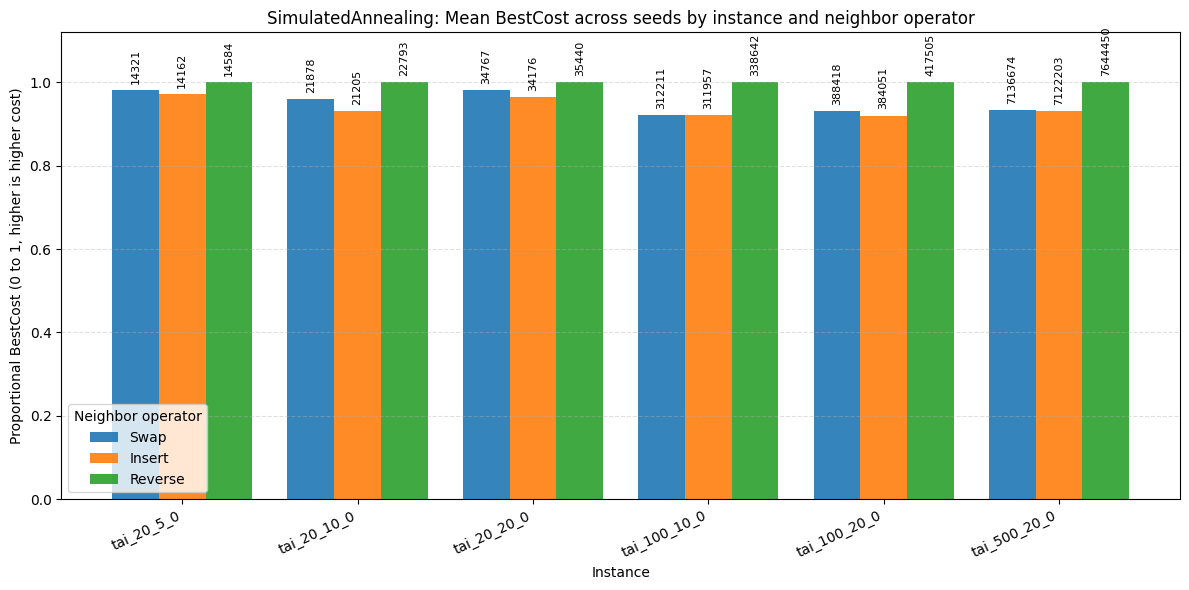

Neighbor,Swap,Insert,Reverse
Instance,,,
tai_20_5_0,0.982008,0.971106,1.0
tai_20_10_0,0.959891,0.930347,1.0
tai_20_20_0,0.980994,0.964335,1.0
tai_100_10_0,0.921952,0.921202,1.0
tai_100_20_0,0.930331,0.919871,1.0
tai_500_20_0,0.933576,0.931683,1.0


In [15]:
import re
from file_io import EXPERIMENTS_ROOT

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_csv = EXPERIMENTS_ROOT / "tai_all_default_simulatedannealing_neighbors_seed" / "experiment_results.csv"
if not results_csv.exists():
    raise FileNotFoundError(f"Expected results file not found: {results_csv.resolve()}")

# Read full results
df = pd.read_csv(results_csv)

# Parse NeighborhoodOperator and Seed from algorithm name: SimulatedAnnealing_n{Neighbor}_i{Iters}_s{Seed}
pattern = re.compile(r"SimulatedAnnealing_n(?P<Neighbor>[^_]+)_i\d+_s(?P<Seed>\d+)")
parsed = df["Algorithm"].str.extract(pattern)
df["Neighbor"] = parsed["Neighbor"]
df["Seed"] = pd.to_numeric(parsed["Seed"], errors="coerce")
df = df.dropna(subset=["Neighbor", "BestCost", "Seed"]).copy()

instance_order = df["Instance"].drop_duplicates().tolist()
operator_order = ["Swap", "Insert", "Reverse"]

# For each Instance x Neighbor x Seed take the best (min) BestCost, then average across seeds
mean_by_seed = df.groupby(["Instance", "Neighbor"], as_index=False)["BestCost"].mean()
pivot = mean_by_seed.pivot(index="Instance", columns="Neighbor", values="BestCost").reindex(index=instance_order, columns=operator_order)

# Per-instance proportional score in [0, 1] computed from averaged BestCost across seeds
row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

x = np.arange(len(instance_order))
width = 0.8 / len(operator_order)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 6))
for idx, op in enumerate(operator_order):
    offset = (idx - (len(operator_order) - 1) / 2) * width
    heights = score_pivot[op].values
    bars = ax.bar(x + offset, heights, width=width, label=op,
                  alpha=0.9, color=colors[idx])

    for bar, val in zip(bars, pivot[op].values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{int(val)}",
                ha="center", va="bottom", fontsize=8, rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instance_order, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("SimulatedAnnealing: Mean BestCost across seeds by instance and neighbor operator")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Neighbor operator")
plt.tight_layout()
plt.show()

score_pivot

# TODOS

## General
* EA and SA additional heuristics
* Restart and barrier breaking
* IRACE?
* Measurement and metadata plug-in

## Experiment
* Generalize runner configuration even more
* DTO unification and cross-program setup
* Test averaging
* Algorithm runtime metadata - not only
* Ablation and other extras

## EA
* Implement different Mutation and Crossover operators
* Start from heuristic solution
* Roulette
* Fitness penalty

# SA
* Cooling schedule comparison

# Fix
* NEH running time
* Missing Random evals and test run
* Make sure Greedy runs once!

# Questions
* Problem formulation
* Should I also optimize SA?
* Computation load, stop conditions, stuck